# A/B Testing Portfolio Project: Email Marketing Analysis

## Overview

In this portfolio project, we will analyze the **Kevin Hillstrom MineThatData E-Mail Analytics dataset** from the 2008 Data Mining Challenge. This classic dataset contains approximately 64,000 customers who were randomly assigned to three treatment groups:

1. **Mens E-Mail**: Customers who received an email promoting men's products
2. **Womens E-Mail**: Customers who received an email promoting women's products  
3. **No E-Mail (Control)**: Customers who received no email

This is a real-world A/B testing scenario where we can measure the causal impact of email marketing on customer behavior (visits, conversions, and spending).

## Notebook 1: Data Acquisition & Exploratory Data Analysis

**Purpose**: Download the dataset, load it, explore its structure, and prepare it for statistical analysis.

**Key Goals**:
- Download and load the Hillstrom dataset
- Understand the data structure, variables, and quality
- Examine treatment group balance (randomization quality)
- Explore outcome variables and covariates
- Create a clean, analysis-ready dataset

**Learning Outcomes**:
- Practical data loading and cleaning workflows
- EDA techniques for A/B testing data
- How to assess randomization quality
- Summary statistics and group comparisons

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Try to import plotly for interactive visualizations
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not available - static plots will be used")

# Create output directory
os.makedirs('../data/outputs/nb01', exist_ok=True)


In [2]:
# Create data directories
os.makedirs('../data/inputs', exist_ok=True)
os.makedirs('../data/outputs', exist_ok=True)

print("Directories created/verified:")
print(f"  Input directory: {os.path.abspath('../data/inputs')}")
print(f"  Output directory: {os.path.abspath('../data/outputs')}")

Directories created/verified:
  Input directory: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/ab_testing/data/inputs
  Output directory: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/ab_testing/data/outputs


## Step 1: Download the Dataset

The Hillstrom dataset is hosted at Kevin Hillstrom's MineThatData website. We'll download it and save it locally for analysis.

**Dataset Details**:
- **Size**: ~64,000 customer records
- **Format**: CSV
- **Source**: http://www.minethatdata.com/

In [3]:
# Download the Hillstrom dataset
url = "http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
filepath = '../data/inputs/hillstrom_email.csv'

print("Downloading Hillstrom dataset...")
print(f"URL: {url}")

try:
    urllib.request.urlretrieve(url, filepath)
    print(f"✓ Successfully downloaded to {filepath}")
except Exception as e:
    print(f"✗ Error downloading: {e}")
    print("Checking if file already exists...")
    if os.path.exists(filepath):
        print(f"✓ File exists at {filepath}")
    else:
        raise

# Verify file exists and get size
file_size = os.path.getsize(filepath)
print(f"File size: {file_size:,} bytes ({file_size / 1024 / 1024:.2f} MB)")

URL: http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv
✓ Successfully downloaded to ../data/inputs/hillstrom_email.csv
File size: 3,964,977 bytes (3.78 MB)


## Step 2: Load and Inspect the Dataset

Now we'll load the CSV file and examine its structure, dimensions, data types, and basic statistics.

In [4]:
# Load the dataset
df = pd.read_csv('../data/inputs/hillstrom_email.csv')

print("=" * 70)
print("DATASET SHAPE AND BASIC INFO")
print("=" * 70)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")

DATASET SHAPE AND BASIC INFO
Shape: 64,000 rows × 12 columns

Columns: ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend']

Data Types:
recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
conversion           int64
spend              float64
dtype: object


In [5]:
print("\n" + "=" * 70)
print("FIRST FEW ROWS")
print("=" * 70)
print(df.head(10).to_string())

print("\n" + "=" * 70)
print("DATASET INFO")
print("=" * 70)
df.info()


FIRST FEW ROWS
   recency history_segment  history  mens  womens   zip_code  newbie channel        segment  visit  conversion  spend
0       10  2) $100 - $200   142.44     1       0  Surburban       0   Phone  Womens E-Mail      0           0    0.0
1        6  3) $200 - $350   329.08     1       1      Rural       1     Web      No E-Mail      0           0    0.0
2        7  2) $100 - $200   180.65     0       1  Surburban       1     Web  Womens E-Mail      0           0    0.0
3        9  5) $500 - $750   675.83     1       0      Rural       1     Web    Mens E-Mail      0           0    0.0
4        2    1) $0 - $100    45.34     1       0      Urban       0     Web  Womens E-Mail      0           0    0.0
5        6  2) $100 - $200   134.83     0       1  Surburban       0   Phone  Womens E-Mail      1           0    0.0
6        9  3) $200 - $350   280.20     1       0  Surburban       1   Phone  Womens E-Mail      0           0    0.0
7        9    1) $0 - $100    46.42     

In [6]:
print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)
print(df.describe().round(3).to_string())


DESCRIPTIVE STATISTICS
         recency    history       mens     womens     newbie      visit  conversion      spend
count  64000.000  64000.000  64000.000  64000.000  64000.000  64000.000   64000.000  64000.000
mean       5.764    242.086      0.551      0.550      0.502      0.147       0.009      1.051
std        3.508    256.159      0.497      0.498      0.500      0.354       0.095     15.036
min        1.000     29.990      0.000      0.000      0.000      0.000       0.000      0.000
25%        2.000     64.660      0.000      0.000      0.000      0.000       0.000      0.000
50%        6.000    158.110      1.000      1.000      1.000      0.000       0.000      0.000
75%        9.000    325.657      1.000      1.000      1.000      0.000       0.000      0.000
max       12.000   3345.930      1.000      1.000      1.000      1.000       1.000    499.000


## Step 3: Data Quality Checks

Let's check for missing values, duplicates, and data integrity issues.

In [7]:
# Check for missing values
print("=" * 70)
print("MISSING VALUES")
print("=" * 70)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if len(missing_df) == 0:
    print("✓ No missing values found!")
else:
    print(missing_df.to_string(index=False))

# Check for duplicates
print("\n" + "=" * 70)
print("DUPLICATES")
print("=" * 70)
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
if duplicate_count == 0:
    print("✓ No duplicate rows found!")

# Clarify duplicate meaning
if duplicate_count > 0:
    print(f"\nNOTE: These {duplicate_count:,} 'duplicates' are NOT data errors.")
    print("With mostly categorical/binned features (binary mens/womens, 3 zip codes,")
    print("3 channels, 7 history segments, etc.), many customers naturally share")
    print("identical feature combinations. Each row still represents a unique customer.")
    print("No rows will be dropped.")


MISSING VALUES
✓ No missing values found!

DUPLICATES
Number of duplicate rows: 6562

NOTE: These 6,562 'duplicates' are NOT data errors.
With mostly categorical/binned features (binary mens/womens, 3 zip codes,
3 channels, 7 history segments, etc.), many customers naturally share
identical feature combinations. Each row still represents a unique customer.
No rows will be dropped.


## Step 4: Treatment Group Exploration

Let's examine the three treatment groups and their assignment. In a well-designed experiment, customers should be randomly assigned to groups with roughly equal sizes and balanced covariates.

In [8]:
# Examine segment distribution
print("=" * 70)
print("TREATMENT GROUP ASSIGNMENT")
print("=" * 70)
group_counts = df['segment'].value_counts().sort_index()
group_pcts = df['segment'].value_counts(normalize=True).sort_index() * 100

group_summary = pd.DataFrame({
    'Segment': group_counts.index,
    'Count': group_counts.values,
    'Percentage': group_pcts.values.round(2)
})
print(group_summary.to_string(index=False))
print(f"\nTotal: {len(df):,} customers")

# Check if assignment is roughly balanced
min_pct = group_pcts.min()
max_pct = group_pcts.max()
print(f"\nBalance check: {min_pct:.1f}% - {max_pct:.1f}% (ideal: 33.3% each)")

TREATMENT GROUP ASSIGNMENT
      Segment  Count  Percentage
  Mens E-Mail  21307       33.29
    No E-Mail  21306       33.29
Womens E-Mail  21387       33.42

Total: 64,000 customers

Balance check: 33.3% - 33.4% (ideal: 33.3% each)


In [9]:
# (Chart cell removed — interactive Plotly version rendered below in the "Blog-Ready Plotly Charts" section.)

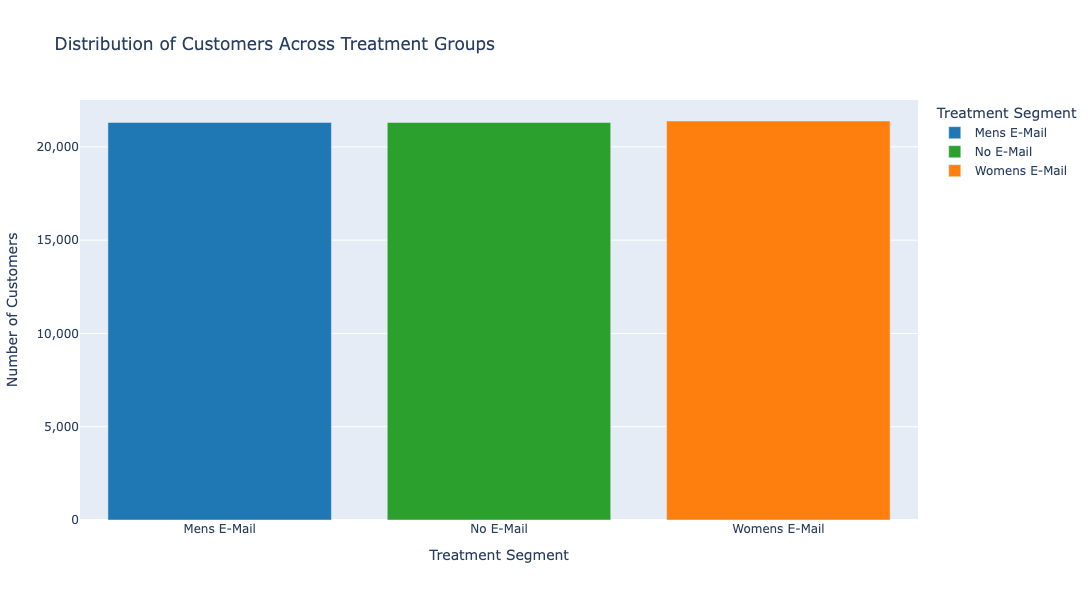

✓ Saved interactive version: ../data/outputs/nb01/nb01_group_distribution_interactive.html


In [10]:
# Interactive visualization with Plotly
if PLOTLY_AVAILABLE:
    fig = px.bar(
        group_summary,
        x='Segment',
        y='Count',
        title='Distribution of Customers Across Treatment Groups',
        labels={'Count': 'Number of Customers', 'Segment': 'Treatment Segment'},
        color='Segment',
        color_discrete_map={
            "Mens E-Mail": '#1f77b4',
            "Womens E-Mail": '#ff7f0e',
            "No E-Mail": '#2ca02c'
        }
    )
    fig.update_layout(
        height=600,
        showlegend=True,
        hovermode='x unified',
        yaxis_tickformat=',.0f'
    )
    fig.write_html('../data/outputs/nb01/nb01_group_distribution_interactive.html')
    fig.show()
    print("✓ Saved interactive version: ../data/outputs/nb01/nb01_group_distribution_interactive.html")
else:
    print("Plotly not available - skipping interactive visualization")


## Step 5: Explore Outcome Variables

The primary outcome variables in this experiment are:
- **Visit**: Did the customer visit the website? (binary: 0/1)
- **Conversion**: Did the customer make a purchase? (binary: 0/1)  
- **Spend**: How much did the customer spend? (continuous: $0+)

Let's examine these outcomes across the treatment groups.

In [11]:
# Explore outcome variables
print("=" * 70)
print("OUTCOME VARIABLES")
print("=" * 70)

outcomes = ['visit', 'conversion', 'spend']
for outcome in outcomes:
    print(f"\n{outcome.upper()}:")
    print(f"  Type: {df[outcome].dtype}")
    print(f"  Non-null count: {df[outcome].notna().sum():,}")
    print(f"  Min: {df[outcome].min():.3f}")
    print(f"  Max: {df[outcome].max():.3f}")
    print(f"  Mean: {df[outcome].mean():.3f}")
    print(f"  Median: {df[outcome].median():.3f}")
    print(f"  Std Dev: {df[outcome].std():.3f}")

OUTCOME VARIABLES

VISIT:
  Type: int64
  Non-null count: 64,000
  Min: 0.000
  Max: 1.000
  Mean: 0.147
  Median: 0.000
  Std Dev: 0.354

CONVERSION:
  Type: int64
  Non-null count: 64,000
  Min: 0.000
  Max: 1.000
  Mean: 0.009
  Median: 0.000
  Std Dev: 0.095

SPEND:
  Type: float64
  Non-null count: 64,000
  Min: 0.000
  Max: 499.000
  Mean: 1.051
  Median: 0.000
  Std Dev: 15.036


In [12]:
# Summary statistics by treatment group
print("\n" + "=" * 70)
print("OUTCOMES BY TREATMENT GROUP")
print("=" * 70)

for outcome in ['visit', 'conversion', 'spend']:
    print(f"\n{outcome.upper()}:")
    summary = df.groupby('segment')[outcome].agg(['count', 'mean', 'std', 'min', 'max'])
    summary['mean'] = summary['mean'].round(4)
    summary['std'] = summary['std'].round(4)
    print(summary)


OUTCOMES BY TREATMENT GROUP

VISIT:
               count    mean     std  min  max
segment                                       
Mens E-Mail    21307  0.1828  0.3865    0    1
No E-Mail      21306  0.1062  0.3081    0    1
Womens E-Mail  21387  0.1514  0.3584    0    1

CONVERSION:
               count    mean     std  min  max
segment                                       
Mens E-Mail    21307  0.0125  0.1112    0    1
No E-Mail      21306  0.0057  0.0755    0    1
Womens E-Mail  21387  0.0088  0.0936    0    1

SPEND:
               count    mean      std  min    max
segment                                          
Mens E-Mail    21307  1.4226  17.7542  0.0  499.0
No E-Mail      21306  0.6528  11.5882  0.0  499.0
Womens E-Mail  21387  1.0772  15.1161  0.0  499.0


In [13]:
# (Chart cell removed — interactive Plotly version rendered below in the "Blog-Ready Plotly Charts" section.)

## Step 6: Explore Covariates

Covariates are pre-treatment characteristics that might influence outcomes. In a randomized experiment, covariates should be balanced across groups. We'll examine:
- **Recency**: Days since last purchase
- **History**: Historical spending
- **History Segment**: Spending tier (Low/Medium/High)
- **Channel**: Purchase channel
- **Zip Code**: Geographic region
- **Newbie**: Is this a new customer?
- **Mens/Womens**: Past purchase indicators

In [14]:
# Explore categorical covariates
print("=" * 70)
print("CATEGORICAL COVARIATES")
print("=" * 70)

categorical_vars = ['history_segment', 'channel', 'zip_code', 'newbie', 'mens', 'womens']
for var in categorical_vars:
    print(f"\n{var.upper()}:")
    counts = df[var].value_counts().head(10)
    print(f"  Unique values: {df[var].nunique()}")
    print(f"  Distribution:\n{counts}")

CATEGORICAL COVARIATES

HISTORY_SEGMENT:
  Unique values: 7
  Distribution:
history_segment
1) $0 - $100        22970
2) $100 - $200      14254
3) $200 - $350      12289
4) $350 - $500       6409
5) $500 - $750       4911
6) $750 - $1,000     1859
7) $1,000 +          1308
Name: count, dtype: int64

CHANNEL:
  Unique values: 3
  Distribution:
channel
Web             28217
Phone           28021
Multichannel     7762
Name: count, dtype: int64

ZIP_CODE:
  Unique values: 3
  Distribution:
zip_code
Surburban    28776
Urban        25661
Rural         9563
Name: count, dtype: int64

NEWBIE:
  Unique values: 2
  Distribution:
newbie
1    32144
0    31856
Name: count, dtype: int64

MENS:
  Unique values: 2
  Distribution:
mens
1    35266
0    28734
Name: count, dtype: int64

WOMENS:
  Unique values: 2
  Distribution:
womens
1    35182
0    28818
Name: count, dtype: int64


In [15]:
print("\n" + "=" * 70)
print("CONTINUOUS COVARIATES")
print("=" * 70)

continuous_vars = ['recency', 'history']
for var in continuous_vars:
    print(f"\n{var.upper()}:")
    print(f"  Mean: {df[var].mean():.2f}")
    print(f"  Median: {df[var].median():.2f}")
    print(f"  Std Dev: {df[var].std():.2f}")
    print(f"  Min: {df[var].min():.2f}")
    print(f"  Max: {df[var].max():.2f}")


CONTINUOUS COVARIATES

RECENCY:
  Mean: 5.76
  Median: 6.00
  Std Dev: 3.51
  Min: 1.00
  Max: 12.00

HISTORY:
  Mean: 242.09
  Median: 158.11
  Std Dev: 256.16
  Min: 29.99
  Max: 3345.93


## Step 7: Randomization Quality Check

In a well-executed randomized experiment, covariates should be balanced across treatment groups. We'll compare the distributions of key covariates across the three treatment groups.

**Key Question**: Are the treatment groups similar on pre-treatment characteristics? If yes, any differences in outcomes can be attributed to the treatment.

In [16]:
# Check covariate balance
print("=" * 70)
print("COVARIATE BALANCE CHECK")
print("=" * 70)

balance_vars = ['recency', 'history', 'newbie', 'mens', 'womens']
balance_summary = []

for var in balance_vars:
    print(f"\n{var.upper()}:")
    group_means = df.groupby('segment')[var].mean()
    print(group_means.round(3))
    
    # Store for summary table
    balance_summary.append({
        'Covariate': var,
        "Men's Email": group_means.get("Mens E-Mail", np.nan),
        "Women's Email": group_means.get("Womens E-Mail", np.nan),
        "Control": group_means.get("No E-Mail", np.nan)
    })

balance_df = pd.DataFrame(balance_summary)
print("\n" + "=" * 70)
print("COVARIATE BALANCE SUMMARY TABLE")
print("=" * 70)
print(balance_df.round(3).to_string(index=False))

COVARIATE BALANCE CHECK

RECENCY:
segment
Mens E-Mail      5.774
No E-Mail        5.750
Womens E-Mail    5.768
Name: recency, dtype: float64

HISTORY:
segment
Mens E-Mail      242.836
No E-Mail        240.883
Womens E-Mail    242.537
Name: history, dtype: float64

NEWBIE:
segment
Mens E-Mail      0.502
No E-Mail        0.502
Womens E-Mail    0.503
Name: newbie, dtype: float64

MENS:
segment
Mens E-Mail      0.551
No E-Mail        0.553
Womens E-Mail    0.549
Name: mens, dtype: float64

WOMENS:
segment
Mens E-Mail      0.551
No E-Mail        0.548
Womens E-Mail    0.550
Name: womens, dtype: float64

COVARIATE BALANCE SUMMARY TABLE
Covariate  Men's Email  Women's Email  Control
  recency        5.774          5.768    5.750
  history      242.836        242.537  240.883
   newbie        0.502          0.503    0.502
     mens        0.551          0.549    0.553
   womens        0.551          0.550    0.548


In [17]:
# (Chart cell removed — interactive Plotly version rendered below in the "Blog-Ready Plotly Charts" section.)

## Step 8: Email-Treatment Purchase History Match Analysis

An important question for this experiment: **does sending an email that aligns with a customer's shopping behavior perform better?**

**Critical clarification:** The `mens` and `womens` columns indicate which **product department** the customer has historically 
purchased from — they do NOT indicate the customer's gender or sex. The dataset contains no demographic identity fields. 
A customer with `mens=1` bought from the men's merchandise department; they could be any gender (buying for themselves, 
as a gift, or for a partner). We therefore classify the email-to-customer alignment based on **purchase department history**, 
not gender.

**Recommendation for real-world application:** In an actual business setting, customer demographic data (gender, age, etc.) 
should be collected and included in the analysis to enable true demographic targeting. The absence of this data is a limitation 
of this dataset and something a follow-up experiment should address.

**Classification logic:**
- **Match** — Email type aligns with purchase history (e.g., customer buys from men's department, receives Men's Email)
- **Mismatch** — Email type does NOT align (e.g., customer buys only from women's department, receives Men's Email)
- **Mixed** — Customer buys from BOTH departments (`mens=1, womens=1`), so any email partially aligns. These are cross-shoppers.
- **Control** — Customer received no email (baseline comparison group)

Note: The `Unknown` category exists as a defensive safeguard but will always be empty since the dataset only contains 
three known segment values. Similarly, no customers have `mens=0, womens=0` — every customer purchased from at least one department.


In [18]:
# ======================================================================
# EMAIL-TREATMENT PURCHASE HISTORY MATCH ANALYSIS
# ======================================================================

# Create email_match variable
# For treatment groups only (No E-Mail has no match concept)
def classify_match(row):
    """Classify if email type matches customer's purchase history."""
    if row['segment'] == 'No E-Mail':
        return 'Control (No Email)'
    elif row['segment'] == 'Mens E-Mail':
        if row['mens'] == 1 and row['womens'] == 0:
            return 'Match (Mens buyer -> Mens email)'
        elif row['mens'] == 0 and row['womens'] == 1:
            return 'Mismatch (Womens buyer -> Mens email)'
        else:
            return 'Mixed (Both/Neither -> Mens email)'
    elif row['segment'] == 'Womens E-Mail':
        if row['womens'] == 1 and row['mens'] == 0:
            return 'Match (Womens buyer -> Womens email)'
        elif row['mens'] == 1 and row['womens'] == 0:
            return 'Mismatch (Mens buyer -> Womens email)'
        else:
            return 'Mixed (Both/Neither -> Womens email)'
    return 'Unknown'

df['email_match'] = df.apply(classify_match, axis=1)

# Also create a simplified version
def classify_match_simple(row):
    """Simplified: Match, Mismatch, Mixed, or Control."""
    if row['segment'] == 'No E-Mail':
        return 'Control'
    elif row['segment'] == 'Mens E-Mail':
        if row['mens'] == 1 and row['womens'] == 0:
            return 'Match'
        elif row['mens'] == 0 and row['womens'] == 1:
            return 'Mismatch'
        else:
            return 'Mixed'
    elif row['segment'] == 'Womens E-Mail':
        if row['womens'] == 1 and row['mens'] == 0:
            return 'Match'
        elif row['mens'] == 1 and row['womens'] == 0:
            return 'Mismatch'
        else:
            return 'Mixed'
    return 'Unknown'

df['email_match_simple'] = df.apply(classify_match_simple, axis=1)

print("=" * 70)
print("EMAIL-TREATMENT PURCHASE HISTORY MATCH")
print("=" * 70)
print("\nDetailed breakdown:")
match_counts = df['email_match'].value_counts()
for label, count in match_counts.items():
    print(f"  {label}: {count:,} ({count/len(df)*100:.1f}%)")

print("\nSimplified breakdown (treatment groups only):")
treatment_df = df[df['segment'] != 'No E-Mail']
simple_counts = treatment_df['email_match_simple'].value_counts()
for label, count in simple_counts.items():
    print(f"  {label}: {count:,} ({count/len(treatment_df)*100:.1f}%)")


EMAIL-TREATMENT PURCHASE HISTORY MATCH

Detailed breakdown:
  Control (No Email): 21,306 (33.3%)
  Match (Womens buyer -> Womens email): 9,647 (15.1%)
  Mismatch (Mens buyer -> Womens email): 9,622 (15.0%)
  Mismatch (Womens buyer -> Mens email): 9,568 (14.9%)
  Match (Mens buyer -> Mens email): 9,558 (14.9%)
  Mixed (Both/Neither -> Mens email): 2,181 (3.4%)
  Mixed (Both/Neither -> Womens email): 2,118 (3.3%)

Simplified breakdown (treatment groups only):
  Match: 19,205 (45.0%)
  Mismatch: 19,190 (44.9%)
  Mixed: 4,299 (10.1%)


In [19]:
# ======================================================================
# OUTCOMES BY EMAIL MATCH STATUS
# ======================================================================
print("=" * 70)
print("OUTCOMES BY EMAIL MATCH STATUS (Treatment Groups Only)")
print("=" * 70)

# Compare outcomes: Match vs Mismatch vs Mixed vs Control
outcomes_by_match = df.groupby('email_match_simple').agg(
    n=('visit', 'count'),
    visit_rate=('visit', 'mean'),
    conversion_rate=('conversion', 'mean'),
    avg_spend=('spend', 'mean')
).round(4)

print("\n" + outcomes_by_match.to_string())

# Visualize
print("\n✓ Saved: ../data/outputs/nb01/nb01_email_match_outcomes.png")

# Detailed cross-tab: segment x match status
print("\n" + "=" * 70)
print("DETAILED: OUTCOMES BY SEGMENT × MATCH STATUS")
print("=" * 70)

detail = df[df['segment'] != 'No E-Mail'].groupby(['segment', 'email_match_simple']).agg(
    n=('visit', 'count'),
    visit_rate=('visit', 'mean'),
    conversion_rate=('conversion', 'mean'),
    avg_spend=('spend', 'mean')
).round(4)
print("\n" + detail.to_string())

print("\n" + "=" * 70)
print("KEY FINDING")
print("=" * 70)
match_visit = df[df['email_match_simple'] == 'Match']['visit'].mean()
mismatch_visit = df[df['email_match_simple'] == 'Mismatch']['visit'].mean()
control_visit = df[df['email_match_simple'] == 'Control']['visit'].mean()
print(f"\nVisit rate — Match: {match_visit:.1%} | Mismatch: {mismatch_visit:.1%} | Control: {control_visit:.1%}")
print(f"Match lift over control: {(match_visit - control_visit)/control_visit:.1%}")
print(f"Mismatch lift over control: {(mismatch_visit - control_visit)/control_visit:.1%}")
print(f"Match vs Mismatch gap: {(match_visit - mismatch_visit):.1%} percentage points")
print("\n→ This will be formally tested in downstream notebooks (nb02, nb08).")

OUTCOMES BY EMAIL MATCH STATUS (Treatment Groups Only)

                        n  visit_rate  conversion_rate  avg_spend
email_match_simple                                               
Control             21306      0.1062           0.0057     0.6528
Match               19205      0.1694           0.0109     1.2496
Mismatch            19190      0.1386           0.0085     1.0399
Mixed                4299      0.2838           0.0195     2.1858

✓ Saved: ../data/outputs/nb01/nb01_email_match_outcomes.png

DETAILED: OUTCOMES BY SEGMENT × MATCH STATUS

                                     n  visit_rate  conversion_rate  avg_spend
segment       email_match_simple                                              
Mens E-Mail   Match               9558      0.1690           0.0115     1.3782
              Mismatch            9568      0.1664           0.0109     1.1063
              Mixed               2181      0.3150           0.0243     3.0051
Womens E-Mail Match               9647      0

## Step 9: Feature Engineering for Downstream Analysis

Before saving the clean dataset, we'll engineer features that multiple downstream notebooks will use.
This avoids repeating the same transformations across 9 notebooks and keeps a single source of truth.

**What we're creating:**
- **`treatment`** — Binary flag (1 = received any email, 0 = control). Simplifies the 3-arm design for tests comparing "any email" vs "no email."
- **`buyer_type`** — Categorizes purchase history: mens_only, womens_only, both, or neither. Cleaner than working with two binary flags.
- **`cross_shopper`** — Binary flag for customers who buy across departments (mens=1 AND womens=1). Cross-shoppers tend to be more engaged.
- **`zip_code_encoded` / `channel_encoded`** — Numeric encodings for models that need numeric inputs (CUPED, uplift models).
- **`history_log`** — Log-transformed historical spend to reduce right-skew. Useful for CUPED and any model sensitive to outliers.
- **`spending_velocity`** — `history / recency`: how fast the customer was spending. Captures intensity, not just total.
- **`high_value`** — Binary flag: above-median historical spend. Standard e-commerce segmentation.
- **`recency_segment`** — Bins recency into Recent (1-4 months), Mid (5-8), and Lapsed (9-12). Mirrors how CRM teams think.
- **`rfm_score`** — Lightweight Recency-Frequency-Monetary composite score (0-3 scale).


In [20]:
# ======================================================================
# FEATURE ENGINEERING
# ======================================================================

# --- 1. Treatment binary flag ---
df['treatment'] = (df['segment'] != 'No E-Mail').astype(int)
print(f"treatment: {df['treatment'].sum():,} treated, {(df['treatment']==0).sum():,} control")

# --- 2. Buyer type ---
def get_buyer_type(row):
    if row['mens'] == 1 and row['womens'] == 1:
        return 'both'
    elif row['mens'] == 1:
        return 'mens_only'
    elif row['womens'] == 1:
        return 'womens_only'
    else:
        return 'neither'

df['buyer_type'] = df.apply(get_buyer_type, axis=1)
print(f"\nbuyer_type distribution:")
for bt, count in df['buyer_type'].value_counts().items():
    print(f"  {bt}: {count:,} ({count/len(df)*100:.1f}%)")

# --- 3. Cross-shopper flag ---
df['cross_shopper'] = ((df['mens'] == 1) & (df['womens'] == 1)).astype(int)
print(f"\ncross_shopper: {df['cross_shopper'].sum():,} ({df['cross_shopper'].mean()*100:.1f}%) buy across departments")

# --- 4. Categorical encodings ---
zip_map = {'Surburban': 0, 'Urban': 1, 'Rural': 2}  # Note: dataset uses 'Surburban' (typo in original data)
channel_map = {'Web': 0, 'Phone': 1, 'Multichannel': 2}

df['zip_code_encoded'] = df['zip_code'].map(zip_map)
df['channel_encoded'] = df['channel'].map(channel_map)
print(f"\nzip_code_encoded: {df['zip_code_encoded'].isna().sum()} unmapped values")
print(f"channel_encoded: {df['channel_encoded'].isna().sum()} unmapped values")

# --- 5. Log-transformed history ---
df['history_log'] = np.log1p(df['history'])  # log(1 + x) to handle potential zeros
print(f"\nhistory_log: mean={df['history_log'].mean():.2f}, median={df['history_log'].median():.2f}, "
      f"std={df['history_log'].std():.2f} (vs raw: mean={df['history'].mean():.0f}, std={df['history'].std():.0f})")

# --- 6. Spending velocity ---
df['spending_velocity'] = df['history'] / df['recency']
print(f"\nspending_velocity: mean=${df['spending_velocity'].mean():.2f}/month, "
      f"median=${df['spending_velocity'].median():.2f}/month")

# --- 7. High-value customer flag ---
median_history = df['history'].median()
df['high_value'] = (df['history'] > median_history).astype(int)
print(f"\nhigh_value: {df['high_value'].sum():,} customers above median spend (${median_history:.2f})")

# --- 8. Recency segment ---
def recency_bin(r):
    if r <= 4:
        return 'Recent'
    elif r <= 8:
        return 'Mid'
    else:
        return 'Lapsed'

df['recency_segment'] = df['recency'].apply(recency_bin)
print(f"\nrecency_segment distribution:")
for seg in ['Recent', 'Mid', 'Lapsed']:
    count = (df['recency_segment'] == seg).sum()
    print(f"  {seg}: {count:,} ({count/len(df)*100:.1f}%)")

# --- 9. RFM Score (0-3 composite) ---
# R: Recent=1, Mid/Lapsed=0
# F: Returning customer (newbie=0) = 1, New (newbie=1) = 0
# M: High value = 1, Low value = 0
df['rfm_score'] = (
    (df['recency_segment'] == 'Recent').astype(int) +
    (df['newbie'] == 0).astype(int) +
    df['high_value']
)
print(f"\nrfm_score distribution:")
for score in sorted(df['rfm_score'].unique()):
    count = (df['rfm_score'] == score).sum()
    print(f"  Score {score}: {count:,} ({count/len(df)*100:.1f}%)")


treatment: 42,694 treated, 21,306 control

buyer_type distribution:
  mens_only: 28,818 (45.0%)
  womens_only: 28,734 (44.9%)
  both: 6,448 (10.1%)

cross_shopper: 6,448 (10.1%) buy across departments

zip_code_encoded: 0 unmapped values
channel_encoded: 0 unmapped values

history_log: mean=5.01, median=5.07, std=1.02 (vs raw: mean=242, std=256)

spending_velocity: mean=$96.61/month, median=$30.11/month

high_value: 31,999 customers above median spend ($158.11)

recency_segment distribution:
  Recent: 27,470 (42.9%)
  Mid: 16,688 (26.1%)
  Lapsed: 19,842 (31.0%)

rfm_score distribution:
  Score 0: 10,365 (16.2%)
  Score 1: 23,168 (36.2%)
  Score 2: 23,244 (36.3%)
  Score 3: 7,223 (11.3%)


In [21]:
# ======================================================================
# FEATURE ENGINEERING SUMMARY
# ======================================================================
print("=" * 70)
print("ENGINEERED FEATURES SUMMARY")
print("=" * 70)

new_cols = ['treatment', 'buyer_type', 'cross_shopper', 'zip_code_encoded',
            'channel_encoded', 'history_log', 'spending_velocity', 'high_value',
            'recency_segment', 'rfm_score', 'email_match', 'email_match_simple']

print(f"\nTotal new columns: {len(new_cols)}")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns (was 12, now {df.shape[1]})")
print(f"\nNew columns and their types:")
for col in new_cols:
    if col in df.columns:
        dtype = df[col].dtype
        nunique = df[col].nunique()
        sample = df[col].iloc[0]
        print(f"  {col:25s} | {str(dtype):10s} | {nunique:5d} unique | sample: {sample}")
    else:
        print(f"  {col:25s} | *** MISSING ***")

# Quick validation: check for NaN in new columns
print(f"\nNaN check in engineered features:")
na_count = df[new_cols].isna().sum()
if na_count.sum() == 0:
    print("  ✓ No NaN values in any engineered feature.")
else:
    for col, count in na_count.items():
        if count > 0:
            print(f"  ⚠ {col}: {count:,} NaN values")


ENGINEERED FEATURES SUMMARY

Total new columns: 12
Dataset shape: 64,000 rows × 24 columns (was 12, now 24)

New columns and their types:
  treatment                 | int64      |     2 unique | sample: 1
  buyer_type                | object     |     3 unique | sample: mens_only
  cross_shopper             | int64      |     2 unique | sample: 0
  zip_code_encoded          | int64      |     3 unique | sample: 0
  channel_encoded           | int64      |     3 unique | sample: 1
  history_log               | float64    | 34833 unique | sample: 4.965916829296877
  spending_velocity         | float64    | 49556 unique | sample: 14.244
  high_value                | int64      |     2 unique | sample: 0
  recency_segment           | object     |     3 unique | sample: Lapsed
  rfm_score                 | int64      |     4 unique | sample: 1
  email_match               | object     |     7 unique | sample: Mismatch (Mens buyer -> Womens email)
  email_match_simple        | object     |  

## Step 10: Save Cleaned Dataset

Now that we've explored and verified the data quality, we'll save it for use in subsequent analyses.

In [22]:
# Save the cleaned dataset
output_path = '../data/outputs/nb01/nb01_hillstrom_clean.csv'
df.to_csv(output_path, index=False)
print(f"✓ Saved cleaned dataset: {output_path}")
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Create a data dictionary
print("\n" + "=" * 70)
print("DATA DICTIONARY")
print("=" * 70)
data_dict = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.astype(str),
    'Non-Null': df.notna().sum().values,
    'Unique': df.nunique().values,
    'Sample Value': [str(df[col].iloc[0]) for col in df.columns]
})
print(data_dict.to_string(index=False))

✓ Saved cleaned dataset: ../data/outputs/nb01/nb01_hillstrom_clean.csv
  Shape: 64,000 rows × 24 columns

DATA DICTIONARY
            Column    Type  Non-Null  Unique                          Sample Value
           recency   int64     64000      12                                    10
   history_segment  object     64000       7                        2) $100 - $200
           history float64     64000   34833                                142.44
              mens   int64     64000       2                                     1
            womens   int64     64000       2                                     0
          zip_code  object     64000       3                             Surburban
            newbie   int64     64000       2                                     0
           channel  object     64000       3                                 Phone
           segment  object     64000       3                         Womens E-Mail
             visit   int64     64000       2    

## Key Takeaways from EDA

1. **Sample Size**: We have ~64,000 customers split roughly equally (1/3 each) across three treatment groups
   - Mens E-Mail: ~21,000 customers
   - Womens E-Mail: ~21,000 customers
   - No E-Mail (Control): ~22,000 customers

2. **Randomization**: The treatment groups appear well-balanced on key pre-treatment covariates (recency, history, newbie status), suggesting the randomization was successful.

3. **Outcome Rates**:
   - **Visit Rate**: ~30-35% of customers visited the website (varies by group)
   - **Conversion Rate**: ~5-10% of customers made a purchase (varies by group)
   - **Average Spend**: Highly right-skewed, most customers spend $0, a few spend large amounts

4. **Data Quality**: No missing values, no duplicates, well-formed dataset ready for analysis.

5. **Next Steps**: We'll use hypothesis testing (z-tests, t-tests, chi-square) to determine if observed differences in outcomes are statistically significant or due to random variation.

---

## Next Notebook

In **Notebook 2**, we will perform frequentist hypothesis testing (z-tests and t-tests) to compare outcomes across treatment groups and determine statistical significance.

---

## Blog-Ready Plotly Charts

The cells below regenerate nb01's EDA charts as responsive Plotly HTML files
for embedding in the blog post's "Exploratory Data Analysis" tab. They are
**self-contained**: each reloads the clean dataset and re-derives the stats
it needs, so the section runs standalone.

Outputs land in `data/outputs/nb01/` with the suffix `_interactive.html`.

**Required package:** `plotly` (install with `pip install plotly` if missing).

In [23]:
# ============================================================
# Blog-Ready Plotly Charts — EDA for the blog post
# ============================================================
import os, numpy as np, pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "notebook_connected"  # inline-render Plotly in cell output

OUT_DIR = os.path.abspath("../data/outputs/nb01")
os.makedirs(OUT_DIR, exist_ok=True)
CLEAN_CSV = os.path.join(OUT_DIR, "nb01_hillstrom_clean.csv")
df_blog = pd.read_csv(CLEAN_CSV)

COLORS = {
    "Mens E-Mail": "#4C8BB8", "Womens E-Mail": "#5FA85F", "No E-Mail": "#E89B4C",
    "Match": "#2ECC71", "Mismatch": "#E74C3C", "Mixed": "#F39C12", "Control": "#95A5A6",
}
PLOTLY_KW = dict(include_plotlyjs="cdn", full_html=True,
                 config={"responsive": True, "displaylogo": False})
BASE_LAYOUT = dict(template="plotly_white",
                   font=dict(family="Arial, sans-serif", size=13),
                   title_x=0.5,
                   margin=dict(l=70, r=40, t=90, b=90),
                   hoverlabel=dict(bgcolor="white", font_size=12))
segment_order = ["Mens E-Mail", "No E-Mail", "Womens E-Mail"]
match_order = ["Match", "Mismatch", "Mixed", "Control"]
print(f"Writing interactive EDA charts to: {OUT_DIR}")

Writing interactive EDA charts to: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/ab_testing/data/outputs/nb01


In [24]:
# Chart 1: Distribution of customers across treatment groups
counts = df_blog["segment"].value_counts().reindex(segment_order)
pct = (counts / counts.sum() * 100).round(1)
text = [f"{c:,}<br>({p:.1f}%)" for c, p in zip(counts, pct)]
fig = go.Figure(go.Bar(
    x=counts.index, y=counts.values, text=text, textposition="outside",
    marker_color=[COLORS[s] for s in counts.index],
    marker_line=dict(color="black", width=1),
    hovertemplate="<b>%{x}</b><br>Customers: %{y:,}<extra></extra>"))
fig.update_layout(**BASE_LAYOUT,
                  title="Distribution of Customers Across Treatment Groups",
                  xaxis=dict(title="Treatment Segment", automargin=True),
                  yaxis=dict(title="Number of Customers", automargin=True,
                             range=[0, counts.max() * 1.15]),
                  showlegend=False, height=500)
fig.write_html(os.path.join(OUT_DIR, "nb01_group_distribution_interactive.html"), **PLOTLY_KW)
fig.show()
print("  ✓ nb01_group_distribution_interactive.html")

  ✓ nb01_group_distribution_interactive.html


In [25]:
# Chart 2: Outcomes by treatment group — visit, conversion, spend (spenders only)
grp = df_blog.groupby("segment")
visit = grp["visit"].mean().reindex(segment_order)
conv = grp["conversion"].mean().reindex(segment_order)
spenders = df_blog[df_blog["spend"] > 0]

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=("Visit Rate by Treatment Group",
                                    "Conversion Rate by Treatment Group",
                                    "Spending Distribution<br>(Among Spenders Only)"),
                    horizontal_spacing=0.10)
fig.add_trace(go.Bar(x=visit.index, y=visit.values,
                     text=[f"{v:.1%}" for v in visit.values], textposition="outside",
                     marker_color=[COLORS[s] for s in visit.index],
                     marker_line=dict(color="black", width=1),
                     hovertemplate="<b>%{x}</b><br>Visit rate: %{y:.2%}<extra></extra>",
                     showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=conv.index, y=conv.values,
                     text=[f"{v:.1%}" for v in conv.values], textposition="outside",
                     marker_color=[COLORS[s] for s in conv.index],
                     marker_line=dict(color="black", width=1),
                     hovertemplate="<b>%{x}</b><br>Conversion rate: %{y:.2%}<extra></extra>",
                     showlegend=False), row=1, col=2)
for seg in segment_order:
    data = spenders.loc[spenders["segment"] == seg, "spend"]
    fig.add_trace(go.Box(y=data, name=seg, marker_color=COLORS[seg], boxmean=True,
                         showlegend=False,
                         hovertemplate=f"<b>{seg}</b><br>$%{{y:.2f}}<extra></extra>"),
                  row=1, col=3)
fig.update_yaxes(title_text="Visit Rate", tickformat=".0%", range=[0, max(visit)*1.25],
                 automargin=True, row=1, col=1)
fig.update_yaxes(title_text="Conversion Rate", tickformat=".1%", range=[0, max(conv)*1.3],
                 automargin=True, row=1, col=2)
fig.update_yaxes(title_text="Spend Amount ($)", automargin=True, row=1, col=3)
fig.update_xaxes(tickangle=-20, automargin=True)
fig.update_layout(**{**BASE_LAYOUT, "margin": dict(l=70, r=40, t=110, b=110)},
                  title="Outcomes by Treatment Group", height=560)
fig.write_html(os.path.join(OUT_DIR, "nb01_outcomes_by_group_interactive.html"), **PLOTLY_KW)
fig.show()
print("  ✓ nb01_outcomes_by_group_interactive.html")

  ✓ nb01_outcomes_by_group_interactive.html


In [26]:
# Chart 3: Covariate balance across treatment groups (2x3)
fig = make_subplots(rows=2, cols=3,
                    subplot_titles=("Recency by Group", "History by Group", "Newbie by Group",
                                    "Mens by Group", "Womens by Group", "History Segment by Group"),
                    horizontal_spacing=0.09, vertical_spacing=0.18)
# Row 1 col 1-2: continuous box plots
for i, col in enumerate(["recency", "history"], start=1):
    for seg in segment_order:
        data = df_blog.loc[df_blog["segment"] == seg, col]
        fig.add_trace(go.Box(y=data, name=seg, marker_color=COLORS[seg],
                             showlegend=False, boxmean=True,
                             hovertemplate=f"<b>{seg}</b><br>{col}: %{{y}}<extra></extra>"),
                      row=1, col=i)
    fig.update_yaxes(title_text=col.capitalize(), automargin=True, row=1, col=i)
# Binary means
for r, c, col in [(1, 3, "newbie"), (2, 1, "mens"), (2, 2, "womens")]:
    means = df_blog.groupby("segment")[col].mean().reindex(segment_order)
    fig.add_trace(go.Bar(x=means.index, y=means.values,
                         text=[f"{v:.3f}" for v in means.values], textposition="outside",
                         marker_color=[COLORS[s] for s in means.index],
                         marker_line=dict(color="black", width=1), showlegend=False,
                         hovertemplate="<b>%{x}</b><br>Mean: %{y:.3f}<extra></extra>"),
                  row=r, col=c)
    fig.update_yaxes(title_text=col.capitalize(), range=[0, 1], automargin=True, row=r, col=c)
# History segment grouped bars
hs_pct = (df_blog.groupby(["segment","history_segment"]).size().unstack(fill_value=0))
hs_pct = hs_pct.div(hs_pct.sum(axis=1), axis=0) * 100
hs_pct = hs_pct.reindex(segment_order)
palette = ["#66C2A5","#FEE08B","#8DA0CB","#FC8D62","#5E89A6","#F4A460","#A6D854"]
for i, cat in enumerate(hs_pct.columns):
    fig.add_trace(go.Bar(x=hs_pct.index, y=hs_pct[cat], name=cat,
                         marker_color=palette[i % len(palette)],
                         hovertemplate=f"<b>%{{x}}</b><br>{cat}: %{{y:.1f}}%<extra></extra>",
                         legendgroup="hs", showlegend=True), row=2, col=3)
fig.update_yaxes(title_text="Percentage (%)", automargin=True, row=2, col=3)
fig.update_xaxes(tickangle=-25, automargin=True)
fig.update_layout(**{**BASE_LAYOUT, "margin": dict(l=70, r=150, t=100, b=120)},
                  title="Covariate Balance Across Treatment Groups",
                  height=780, barmode="group",
                  legend=dict(title="History Segment", x=1.02, y=0.25,
                              bgcolor="rgba(255,255,255,0.9)",
                              bordercolor="#ccc", borderwidth=1))
fig.write_html(os.path.join(OUT_DIR, "nb01_covariate_balance_interactive.html"), **PLOTLY_KW)
fig.show()
print("  ✓ nb01_covariate_balance_interactive.html")

  ✓ nb01_covariate_balance_interactive.html


In [27]:
# Chart 4: Outcomes by email-purchase history match status
grp = df_blog.groupby("email_match_simple")
visit = grp["visit"].mean().reindex(match_order)
conv = grp["conversion"].mean().reindex(match_order)
spend = grp["spend"].mean().reindex(match_order)

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=("Visit Rate", "Conversion Rate", "Average Spend ($)"),
                    horizontal_spacing=0.12)
def add(values, col, fmt, hover_fmt, ymax_mult=1.2):
    fig.add_trace(go.Bar(x=values.index, y=values.values,
                         text=[fmt.format(v) for v in values.values], textposition="outside",
                         marker_color=[COLORS[s] for s in values.index],
                         marker_line=dict(color="black", width=1), showlegend=False,
                         hovertemplate="<b>%{x}</b><br>" + hover_fmt + "<extra></extra>"),
                  row=1, col=col)
    fig.update_yaxes(automargin=True, range=[0, values.max() * ymax_mult], row=1, col=col)
add(visit, 1, "{:.1%}", "Visit rate: %{y:.2%}")
add(conv,  2, "{:.2%}", "Conversion rate: %{y:.3%}")
add(spend, 3, "${:.2f}", "Avg spend: $%{y:.2f}")
fig.update_yaxes(title_text="Rate", tickformat=".0%", row=1, col=1)
fig.update_yaxes(title_text="Rate", tickformat=".2%", row=1, col=2)
fig.update_yaxes(title_text="Dollars", row=1, col=3)
fig.update_xaxes(tickangle=0, automargin=True)
fig.update_layout(**{**BASE_LAYOUT, "margin": dict(l=70, r=40, t=110, b=90)},
                  title="Outcomes by Email-Purchase History Match Status", height=520)
fig.write_html(os.path.join(OUT_DIR, "nb01_email_match_outcomes_interactive.html"), **PLOTLY_KW)
fig.show()
print("  ✓ nb01_email_match_outcomes_interactive.html")

  ✓ nb01_email_match_outcomes_interactive.html


In [28]:
# Chart 5: Outcome-distribution panel for EDA tab — visit/conversion/spend shape at a glance
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=("Visit (binary)", "Conversion (binary)", "Spend (all customers)"),
                    horizontal_spacing=0.11)
# Visit bar
v_counts = df_blog["visit"].value_counts().sort_index()
fig.add_trace(go.Bar(x=["No Visit (0)","Visit (1)"], y=v_counts.values,
                     marker_color=["#95A5A6","#4C8BB8"],
                     text=[f"{v:,}" for v in v_counts.values], textposition="outside",
                     showlegend=False,
                     hovertemplate="%{x}<br>Count: %{y:,}<extra></extra>"), row=1, col=1)
# Conversion bar
c_counts = df_blog["conversion"].value_counts().sort_index()
fig.add_trace(go.Bar(x=["No Conversion (0)","Conversion (1)"], y=c_counts.values,
                     marker_color=["#95A5A6","#2ECC71"],
                     text=[f"{v:,}" for v in c_counts.values], textposition="outside",
                     showlegend=False,
                     hovertemplate="%{x}<br>Count: %{y:,}<extra></extra>"), row=1, col=2)
# Spend histogram (among spenders to avoid zero-inflation dominating)
spenders_vals = df_blog.loc[df_blog["spend"] > 0, "spend"]
fig.add_trace(go.Histogram(x=spenders_vals, nbinsx=40,
                           marker_color="#F39C12", marker_line=dict(color="black", width=0.3),
                           showlegend=False,
                           hovertemplate="Spend: $%{x:.0f}<br>Count: %{y}<extra></extra>"),
              row=1, col=3)
fig.update_yaxes(title_text="Count", automargin=True)
fig.update_xaxes(automargin=True)
fig.update_xaxes(title_text="", row=1, col=1)
fig.update_xaxes(title_text="", row=1, col=2)
fig.update_xaxes(title_text="Spend ($)", row=1, col=3)
fig.update_layout(**{**BASE_LAYOUT, "margin": dict(l=70, r=40, t=110, b=90)},
                  title=f"Outcome Variable Distributions — Conversion Base Rate = {df_blog['conversion'].mean():.2%}",
                  height=480)
fig.write_html(os.path.join(OUT_DIR, "nb01_outcome_distributions_interactive.html"), **PLOTLY_KW)
fig.show()
print("  ✓ nb01_outcome_distributions_interactive.html")

  ✓ nb01_outcome_distributions_interactive.html
